### Importing Libraries

In [88]:
import pyodbc

import pandas as pd 
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from imblearn.over_sampling import SMOTE

import os

import joblib

import warnings
warnings.filterwarnings('ignore')

### SQL Connection

In [40]:
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'SQL Server Native Client RDA 11.0', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [41]:
server = 'DESKTOP-H9055HU\SQLEXPRESS' 
database = 'HealthcareDB' 

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

query = "SELECT * FROM GoldPatientFeatures"

In [42]:
df = pd.read_sql(query, conn)
df.head()

,patient_id,full_name,gender,age,city,blood_type,insurance_provider,total_appointments,last_appointment_date,avg_consultation_fee,...,last_lab_abnormal,num_doctors_seen,most_frequent_doctor_id,last_doctor_id,avg_days_between_appointments,lab_abnormal_ratio,has_cardiology_appointment,has_dermatology_appointment,has_neurology_appointment,has_orthopedics_appointment
0,100425,Carlos Khan,Male,52,Antalya,A+,MediPlus,3,2023-02-11,125.0,...,True,3,384393.0,886651.0,501.0,0.50,False,True,True,True
1,100599,Carlos Silva,Female,72,Ankara,B-,SGK,3,2024-11-01,100.0,...,True,3,779215.0,779215.0,559.0,0.67,False,True,False,True
2,101773,Sofia Rossi,Female,65,İstanbul,B-,PrivateCare,2,2022-09-03,100.0,...,False,2,906776.0,993023.0,926.0,0.00,False,True,True,False
3,102260,Aisha Ivanov,Female,72,Ankara,A-,HealthCo,4,2025-03-12,175.0,...,True,4,904441.0,904441.0,489.0,0.50,False,False,True,True
4,102805,Sofia Garcia,Female,40,Ankara,AB+,None,2,2024-09-03,100.0,...,False,2,647242.0,647242.0,886.0,0.00,True,False,False,True


### EDA

In [43]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 1200
Number of columns: 21


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     1200 non-null   int64  
 1   full_name                      1200 non-null   str    
 2   gender                         1200 non-null   str    
 3   age                            1200 non-null   int64  
 4   city                           1200 non-null   str    
 5   blood_type                     1200 non-null   str    
 6   insurance_provider             1200 non-null   str    
 7   total_appointments             1200 non-null   int64  
 8   last_appointment_date          1083 non-null   object 
 9   avg_consultation_fee           1083 non-null   float64
 10  total_abnormal_labs            1200 non-null   int64  
 11  last_lab_abnormal              1200 non-null   bool   
 12  num_doctors_seen               1200 non-null   int64  
 13 

In [45]:
# Remove records unnecessary for modeling and that could lead to data leakage
df.drop(columns = ['patient_id', 'full_name', 'most_frequent_doctor_id', 'last_doctor_id'], inplace=True)

In [46]:
# Fill missing values with 0, which is appropriate for this dataset as it indicates the absence of a feature (e.g., no consultation fee, no cardiology appointment, etc.)
df.fillna(0, inplace=True)

,gender,age,city,blood_type,insurance_provider,total_appointments,last_appointment_date,avg_consultation_fee,total_abnormal_labs,last_lab_abnormal,num_doctors_seen,avg_days_between_appointments,lab_abnormal_ratio,has_cardiology_appointment,has_dermatology_appointment,has_neurology_appointment,has_orthopedics_appointment
0,Male,52,Antalya,A+,MediPlus,3,2023-02-11,125.00,1,True,3,501.0,0.50,False,True,True,True
1,Female,72,Ankara,B-,SGK,3,2024-11-01,100.00,2,True,3,559.0,0.67,False,True,False,True
2,Female,65,İstanbul,B-,PrivateCare,2,2022-09-03,100.00,0,False,2,926.0,0.00,False,True,True,False
3,Female,72,Ankara,A-,HealthCo,4,2025-03-12,175.00,2,True,4,489.0,0.50,False,False,True,True
4,Female,40,Ankara,AB+,None,2,2024-09-03,100.00,0,False,2,886.0,0.00,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Female,73,Bursa,Unknown,HealthCo,3,2025-04-11,133.33,0,False,3,872.0,0.00,False,False,False,True
1196,Male,13,İzmir,Unknown,PrivateCare,1,2020-06-27,50.00,0,False,1,0.0,0.00,True,False,False,False
1197,Male,16,İzmir,A+,None,4,2024-03-13,93.75,0,False,4,418.0,0.00,True,False,True,False
1198,Female,67,Bursa,AB+,HealthCo,4,2023-03-06,162.50,0,False,4,310.0,0.00,True,False,True,True


In [47]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['last_lab_abnormal'] = df['last_lab_abnormal'].astype('int')
df['has_cardiology_appointment'] = df['has_cardiology_appointment'].astype('int')
df['has_dermatology_appointment'] = df['has_dermatology_appointment'].astype('int')
df['has_neurology_appointment'] = df['has_neurology_appointment'].astype('int')
df['has_orthopedics_appointment'] = df['has_orthopedics_appointment'].astype('int')

In [48]:
# Remove records with zero consultation fee because they did not have a consultation and thus do not contribute to risk score modeling
df.drop(df[df['avg_consultation_fee'] == 0].index, inplace=True)

In [49]:
# Optimize data types for memory efficiency
df[['gender', 
   'has_cardiology_appointment', 
   'has_dermatology_appointment', 
   'has_neurology_appointment', 
   'has_orthopedics_appointment']] = df[[ 'gender', 'has_cardiology_appointment', 'has_dermatology_appointment', 'has_neurology_appointment', 'has_orthopedics_appointment']].astype('int8')

df['last_appointment_date'] = pd.to_datetime(df['last_appointment_date'], format = '%Y-%m-%d')

df['age'] = df['age'].astype('int16')

In [50]:
df.select_dtypes(include=[np.number]).describe().T

,count,mean,std,min,25%,50%,75%,max
gender,1083.0,0.477378,0.499719,0.0,0.0,0.0,1.00,1.0
age,1083.0,42.884580,20.014149,8.0,26.0,43.0,61.00,76.0
total_appointments,1083.0,4.357341,2.008464,1.0,3.0,4.0,6.00,11.0
avg_consultation_fee,1083.0,114.924340,30.437925,50.0,95.0,112.5,133.33,200.0
total_abnormal_labs,1083.0,1.559557,1.424277,0.0,0.0,1.0,2.00,8.0
last_lab_abnormal,1083.0,0.743306,0.437011,0.0,0.0,1.0,1.00,1.0
num_doctors_seen,1083.0,4.272392,1.952449,1.0,3.0,4.0,6.00,10.0
avg_days_between_appointments,1083.0,382.881810,271.952037,0.0,229.0,329.0,456.00,1855.0
lab_abnormal_ratio,1083.0,0.470720,0.356773,0.0,0.0,0.5,0.75,1.0
has_cardiology_appointment,1083.0,0.622345,0.485025,0.0,0.0,1.0,1.00,1.0


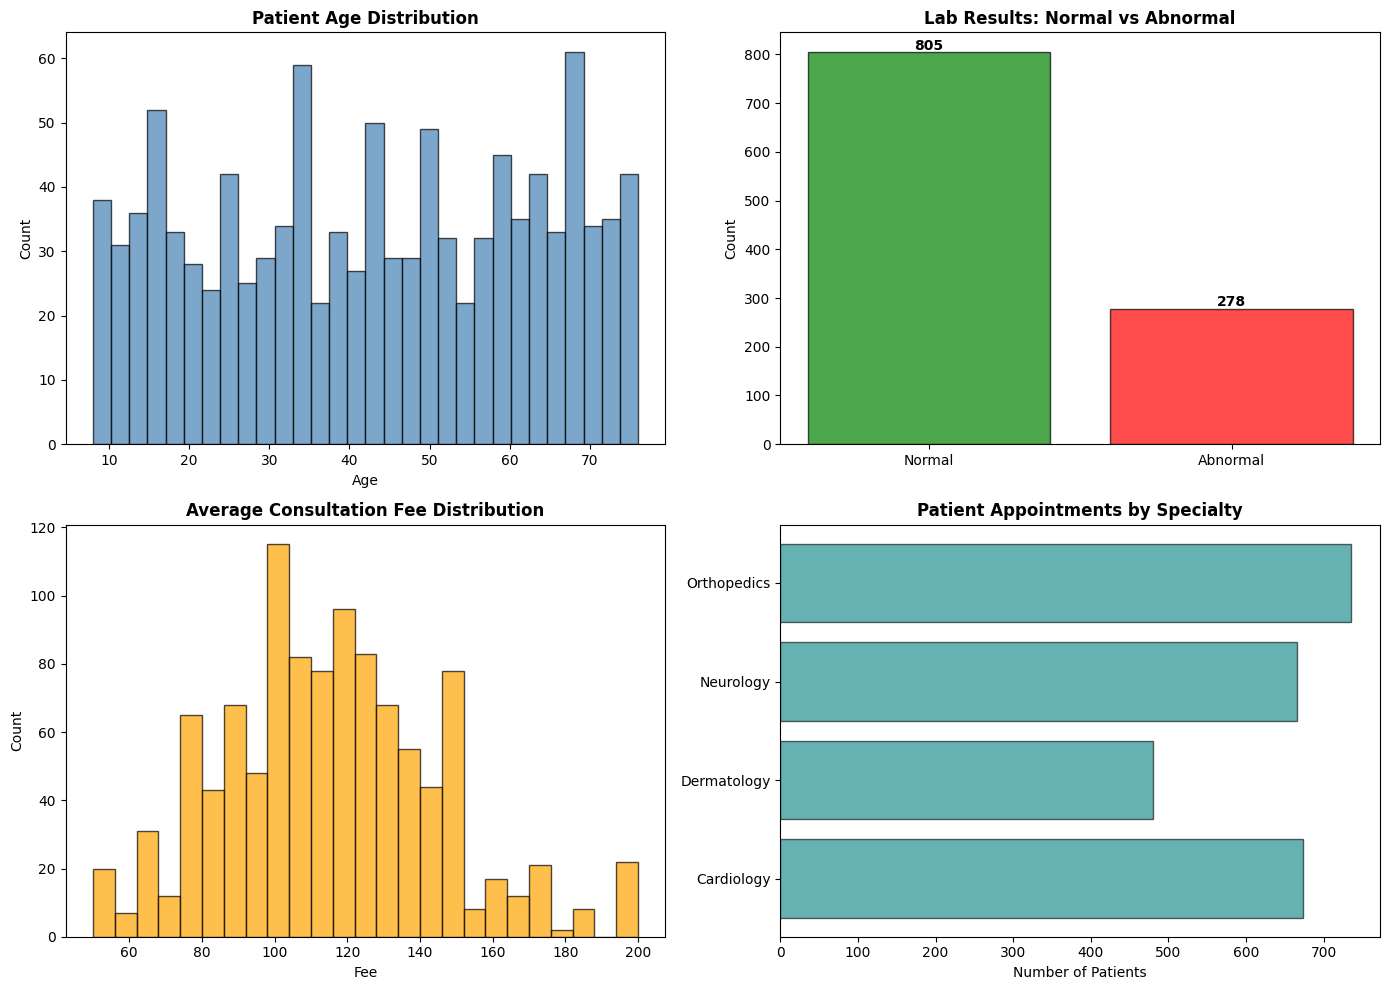


KEY INSIGHTS:
• Total Patients: 1083
• Average Age: 42.9 years
• Lab Abnormality Rate: 74.3%
• Average Consultation Fee: $114.92


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age Distribution (important risk factor)
axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Patient Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# 2. Lab Abnormality Rate (critical health indicator)
abnormal_counts = df['last_lab_abnormal'].value_counts()
axes[0, 1].bar(['Normal', 'Abnormal'], abnormal_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Lab Results: Normal vs Abnormal', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(abnormal_counts.values):
    axes[0, 1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3. Consultation Fee Distribution
axes[1, 0].hist(df['avg_consultation_fee'], bins=25, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Consultation Fee Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fee')
axes[1, 0].set_ylabel('Count')

# 4. Appointment Specialties (healthcare usage pattern)
specialty_cols = ['has_cardiology_appointment', 'has_dermatology_appointment', 
                'has_neurology_appointment', 'has_orthopedics_appointment']
specialty_counts = df[specialty_cols].sum()
specialty_names = ['Cardiology', 'Dermatology', 'Neurology', 'Orthopedics']
axes[1, 1].barh(specialty_names, specialty_counts.values, color='teal', edgecolor='black', alpha=0.6)
axes[1, 1].set_title('Patient Appointments by Specialty', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Patients')

plt.tight_layout()
plt.show()

print("\nKEY INSIGHTS:")
print(f"• Total Patients: {len(df)}")
print(f"• Average Age: {df['age'].mean():.1f} years")
print(f"• Lab Abnormality Rate: {(df['last_lab_abnormal'].sum() / len(df) * 100):.1f}%")
print(f"• Average Consultation Fee: ${df['avg_consultation_fee'].mean():.2f}")

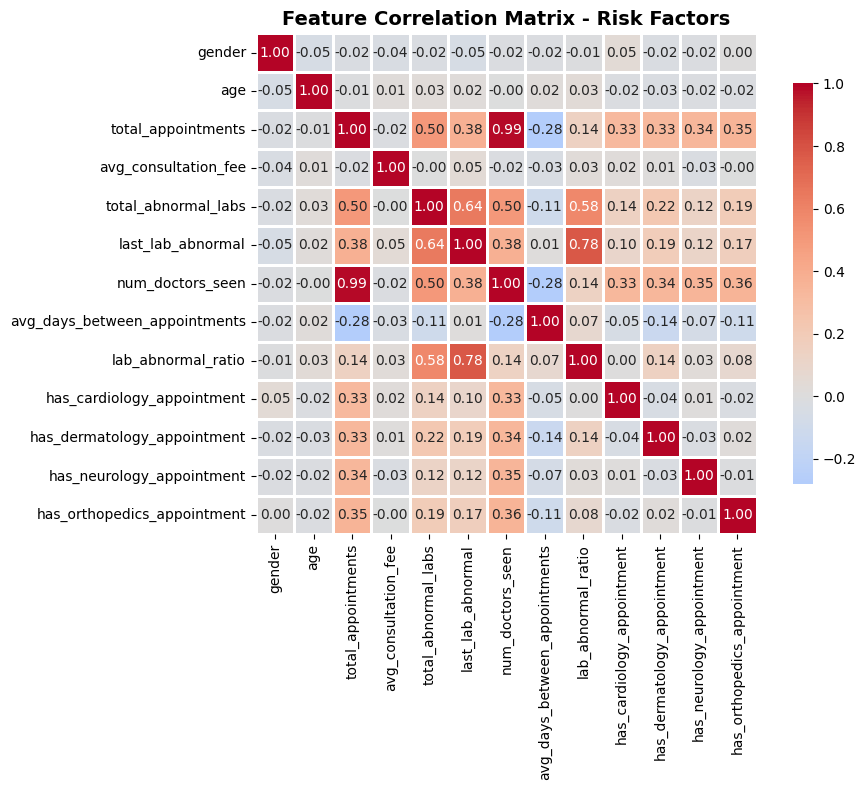

In [52]:
# Corelation Matrix - To see relationships between risk factors 
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix - Risk Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

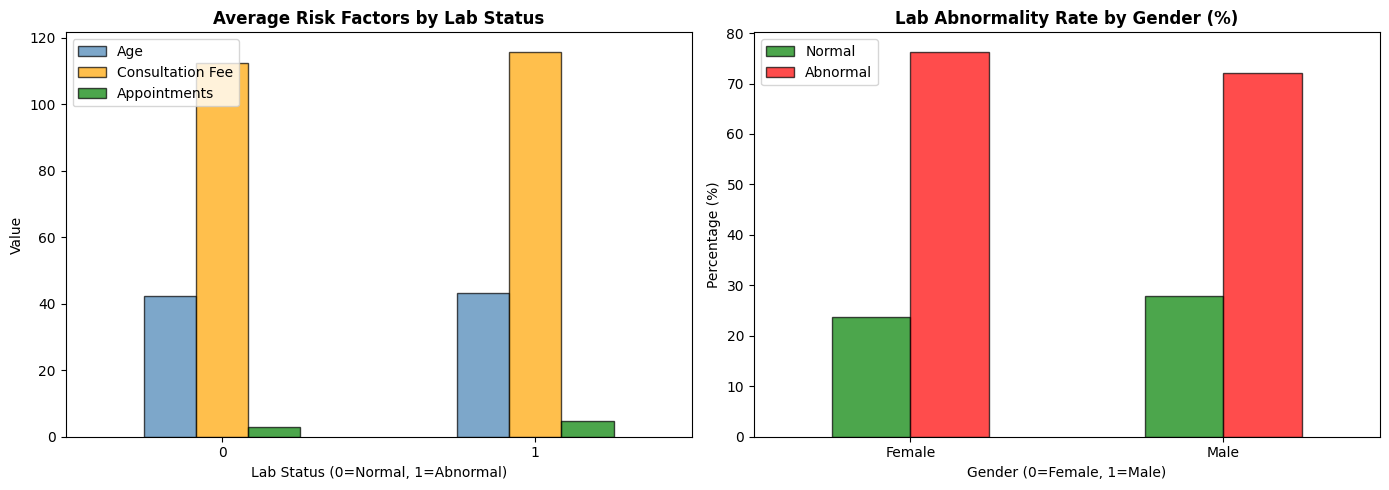


RISK PROFILE INSIGHTS:
• Normal Patients - Avg Age: 42.2, Appointments: 3.1
• Abnormal Patients - Avg Age: 43.1, Appointments: 4.8


In [53]:
# Risk Profiling - Finding the most risky patient combinations
# Average risk factors by lab status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_comparison = df.groupby('last_lab_abnormal')[['age', 'avg_consultation_fee', 'total_appointments']].mean()
risk_comparison.plot(kind='bar', ax=axes[0], color=['steelblue', 'orange', 'green'], alpha=0.7, edgecolor='black')
axes[0].set_title('Average Risk Factors by Lab Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lab Status (0=Normal, 1=Abnormal)')
axes[0].set_ylabel('Value')
axes[0].legend(['Age', 'Consultation Fee', 'Appointments'], loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Risk factors by gender and lab status
abnorm_gender = pd.crosstab(df['gender'], df['last_lab_abnormal'], margins=True)
abnorm_gender.drop('All', axis=1, inplace=True)
abnorm_gender.drop('All', axis=0, inplace=True)
abnorm_gender_pct = abnorm_gender.div(abnorm_gender.sum(axis=1), axis=0) * 100
abnorm_gender_pct.plot(kind='bar', ax=axes[1], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Lab Abnormality Rate by Gender (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['Normal', 'Abnormal'])

plt.tight_layout()
plt.show()

print("\nRISK PROFILE INSIGHTS:")
print(f"• Normal Patients - Avg Age: {df[df['last_lab_abnormal']==0]['age'].mean():.1f}, Appointments: {df[df['last_lab_abnormal']==0]['total_appointments'].mean():.1f}")
print(f"• Abnormal Patients - Avg Age: {df[df['last_lab_abnormal']==1]['age'].mean():.1f}, Appointments: {df[df['last_lab_abnormal']==1]['total_appointments'].mean():.1f}")

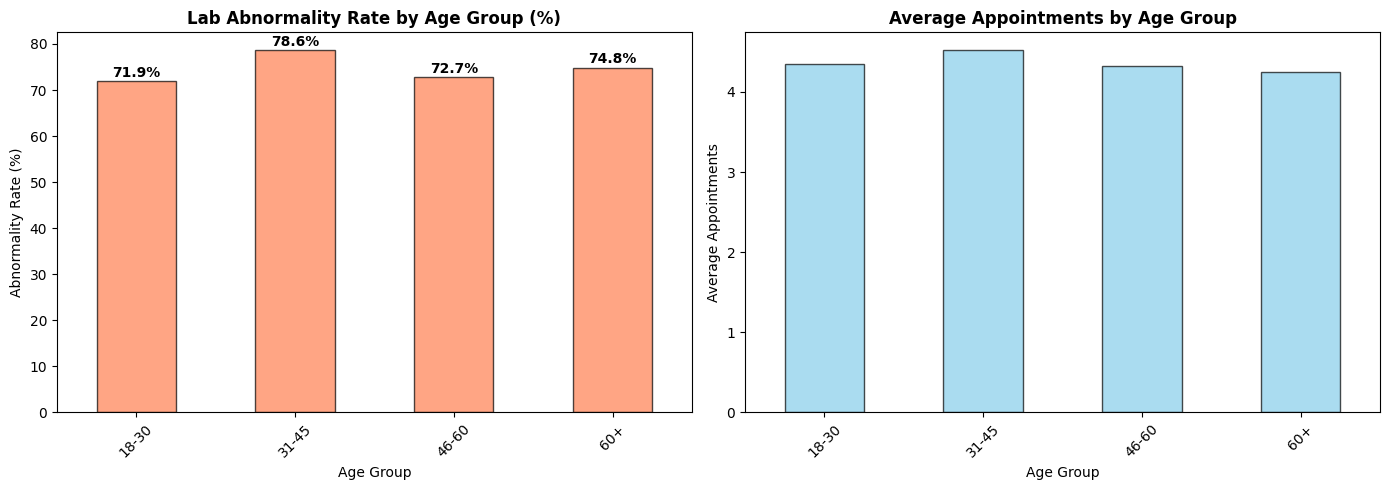

In [54]:
# Risk Profiling by Age Groups - To identify which age groups are most at risk
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])

age_risk_analysis = df.groupby('age_group', observed=True).agg({
    'last_lab_abnormal': ['sum', 'count', 'mean'],
    'total_appointments': 'mean',
    'avg_consultation_fee': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group-wise abnormality rate
abnormal_by_age = df.groupby('age_group', observed=True)['last_lab_abnormal'].mean() * 100
abnormal_by_age.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Lab Abnormality Rate by Age Group (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Abnormality Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
for i, v in enumerate(abnormal_by_age):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Age group-wise average appointment count
appt_by_age = df.groupby('age_group', observed=True)['total_appointments'].mean()
appt_by_age.plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Average Appointments by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Appointments')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

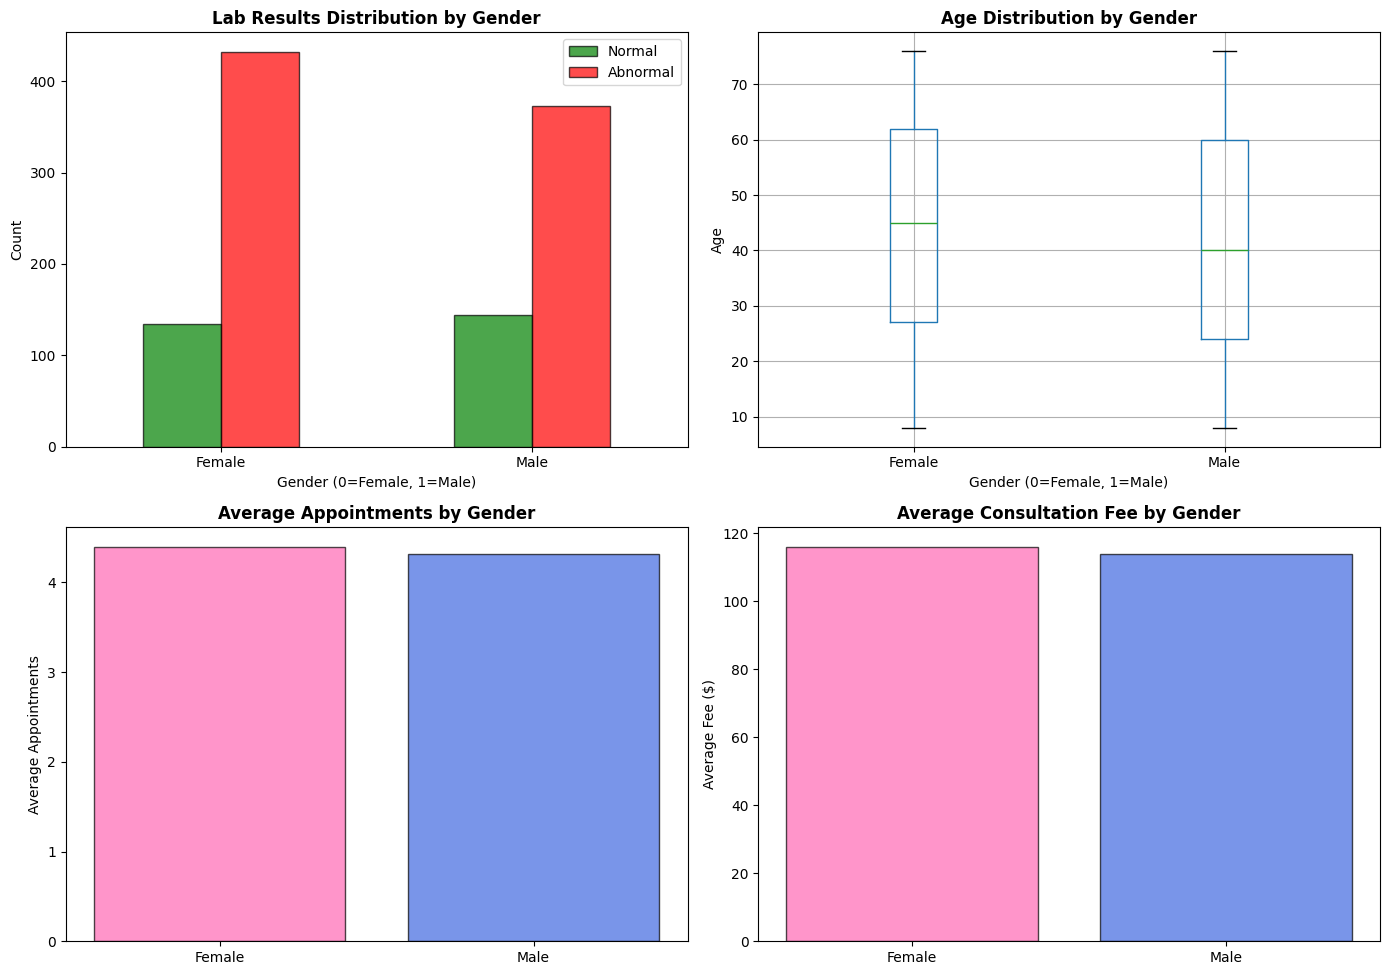

In [55]:
# Anomality vs Gender - According to gender, how do health outcomes differ?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

gender_labels = {0: 'Female', 1: 'Male'}
colors = ['#FF69B4', '#4169E1']

# Distribution of abnormalities by gender
gender_abnormal = pd.crosstab(df['gender'], df['last_lab_abnormal'])
gender_abnormal.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Lab Results Distribution by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gender (0=Female, 1=Male)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0, 0].legend(['Normal', 'Abnormal'])

# Distribution of abnormalities by age
df.boxplot(column='age', by='gender', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gender (0=Female, 1=Male)')
axes[0, 1].set_ylabel('Age')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Female', 'Male'])

# Distribution of average appointments by gender
appt_by_gender = df.groupby('gender')['total_appointments'].mean()
axes[1, 0].bar(['Female', 'Male'], appt_by_gender.values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Average Appointments by Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Appointments')

# Distribution of average consultation fee by gender
fee_by_gender = df.groupby('gender')['avg_consultation_fee'].mean()
axes[1, 1].bar(['Female', 'Male'], fee_by_gender.values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Average Consultation Fee by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Fee ($)')

plt.suptitle('')
plt.tight_layout()
plt.show()

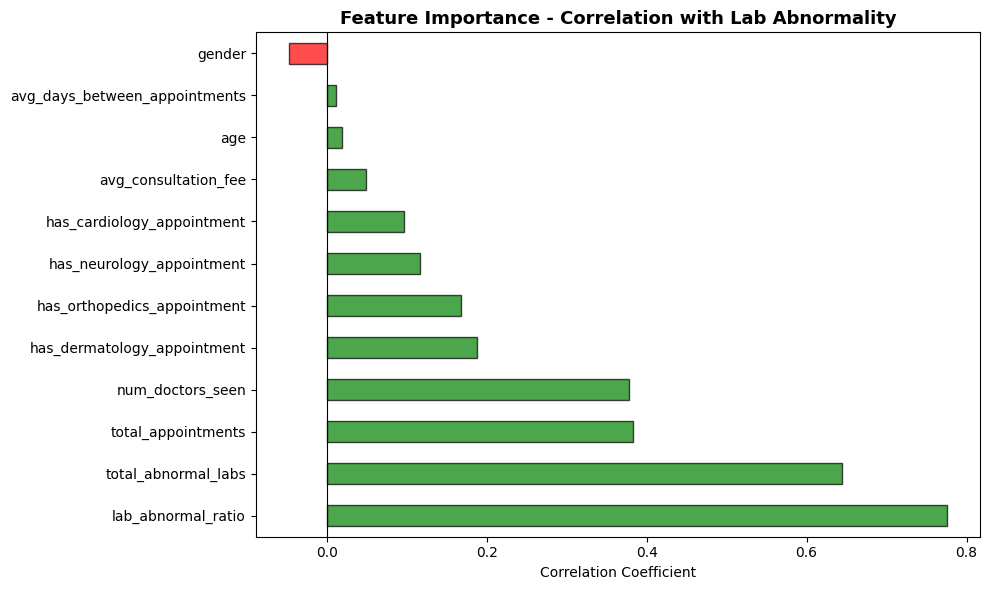

In [56]:
# 5. Feature Importance - To identify which features are most strongly correlated with lab abnormalities and thus most important for risk scoring
# Calculate correlation with abnormality (target)
feature_importance = df.select_dtypes(include=[np.number]).corr()['last_lab_abnormal'].sort_values(ascending=False)
feature_importance = feature_importance.drop('last_lab_abnormal')  # Kendisini kaldır

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['red' if x < 0 else 'green' for x in feature_importance.values]
feature_importance.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='black', alpha=0.7)
ax.set_title('Feature Importance - Correlation with Lab Abnormality', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

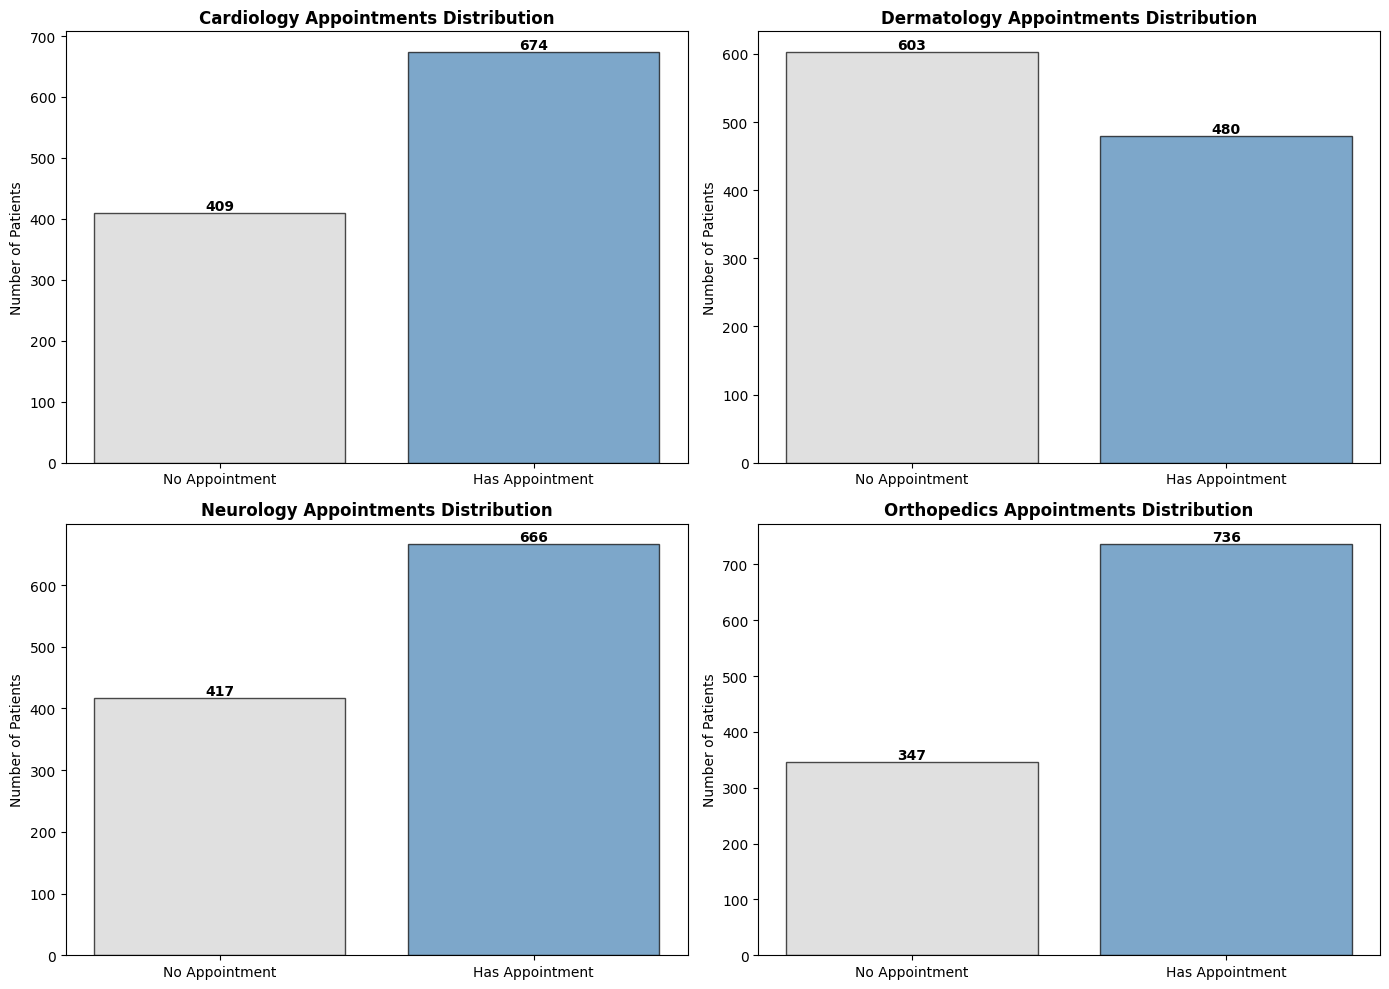

In [57]:
# Specialty Appointments vs Lab Abnormality -
# To see if having appointments in certain specialties is associated with higher or lower rates of lab abnormalities, which can inform risk scoring based on healthcare usage patterns
specialty_cols = ['has_cardiology_appointment', 'has_dermatology_appointment', 
                'has_neurology_appointment', 'has_orthopedics_appointment']
specialty_names = ['Cardiology', 'Dermatology', 'Neurology', 'Orthopedics']

# Lab abnormality rate by specialty appointment status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # 2D array to 1D array for easier indexing

for idx, (col, name) in enumerate(zip(specialty_cols, specialty_names)):
    abnormal_rate = df.groupby(col)['last_lab_abnormal'].mean() * 100
    
    data_to_plot = [
        len(df[df[col] == 0]),
        len(df[df[col] == 1])
    ]
    
    bars = axes[idx].bar(['No Appointment', 'Has Appointment'], data_to_plot, 
                        color=['lightgray', 'steelblue'], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{name} Appointments Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Number of Patients')
    
    # Add value labels on top of bars
    for bar, val in zip(bars, data_to_plot):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(val)}',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Data Preprocessing

In [58]:
df.drop(columns=['age', 'last_appointment_date', 'city', 'num_doctors_seen'], inplace=True)

In [59]:
df.head()

,gender,blood_type,insurance_provider,total_appointments,avg_consultation_fee,total_abnormal_labs,last_lab_abnormal,avg_days_between_appointments,lab_abnormal_ratio,has_cardiology_appointment,has_dermatology_appointment,has_neurology_appointment,has_orthopedics_appointment,age_group
0,1,A+,MediPlus,3,125.0,1,1,501.0,0.50,0,1,1,1,46-60
1,0,B-,SGK,3,100.0,2,1,559.0,0.67,0,1,0,1,60+
2,0,B-,PrivateCare,2,100.0,0,0,926.0,0.00,0,1,1,0,60+
3,0,A-,HealthCo,4,175.0,2,1,489.0,0.50,0,0,1,1,60+
4,0,AB+,None,2,100.0,0,0,886.0,0.00,1,0,0,1,31-45


In [67]:
# Define columns to encode
columns_to_encode = ['blood_type', 'insurance_provider', 'age_group']

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the data
encoded_data = encoder.fit_transform(df[columns_to_encode])

# Get the feature names after encoding
encoded_columns = encoder.get_feature_names_out(columns_to_encode)

# Create a DataFrame with encoded columns
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns, index=df.index)

# Drop original columns and concatenate encoded columns
df_encoded = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)

print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(f"\nNew columns after encoding:\n{list(encoded_df.columns)}")

Original shape: (1083, 14)
Encoded shape: (1083, 27)

New columns after encoding:
['blood_type_A+', 'blood_type_A-', 'blood_type_AB+', 'blood_type_B+', 'blood_type_B-', 'blood_type_O+', 'blood_type_Unknown', 'insurance_provider_HealthCo', 'insurance_provider_MediPlus', 'insurance_provider_None', 'insurance_provider_PrivateCare', 'insurance_provider_SGK', 'age_group_18-30', 'age_group_31-45', 'age_group_46-60', 'age_group_60+']


In [68]:
df_encoded.head()

,gender,total_appointments,avg_consultation_fee,total_abnormal_labs,last_lab_abnormal,avg_days_between_appointments,lab_abnormal_ratio,has_cardiology_appointment,has_dermatology_appointment,has_neurology_appointment,...,blood_type_Unknown,insurance_provider_HealthCo,insurance_provider_MediPlus,insurance_provider_None,insurance_provider_PrivateCare,insurance_provider_SGK,age_group_18-30,age_group_31-45,age_group_46-60,age_group_60+
0,1,3,125.0,1,1,501.0,0.50,0,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,3,100.0,2,1,559.0,0.67,0,1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0,2,100.0,0,0,926.0,0.00,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0,4,175.0,2,1,489.0,0.50,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,2,100.0,0,0,886.0,0.00,1,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [69]:
# Update df to use encoded data for further analysis
df = df_encoded.copy()
print(f"Updated df with encoded columns. Shape: {df.shape}")

Updated df with encoded columns. Shape: (1083, 27)


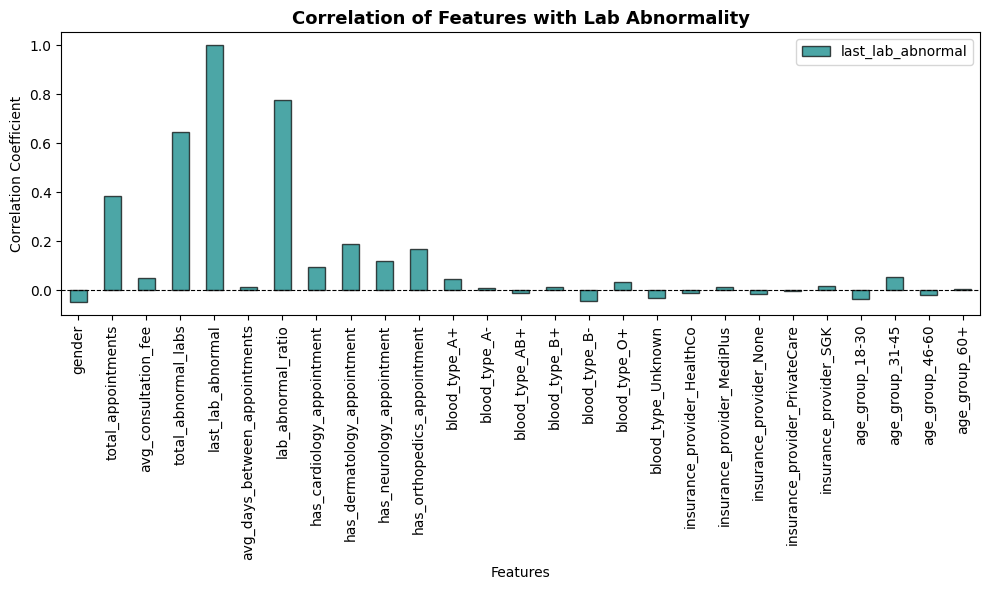

In [70]:
df.corr().plot(kind='bar', y='last_lab_abnormal', figsize=(10, 6), color='teal', edgecolor='black', alpha=0.7)
plt.title('Correlation of Features with Lab Abnormality', fontsize=13, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### Train/Val/Test Split (60%, 20%, 20%)

In [ ]:
# Prepare features and target
X = df.drop('last_lab_abnormal', axis=1)
y = df['last_lab_abnormal']

print(f"\nTotal samples: {len(X)}")

# First split: 60% train, 40% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: Split temp into 50% val, 50% test (20% val, 20% test of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

train_pct = len(X_train) / len(X) * 100
val_pct = len(X_val) / len(X) * 100
test_pct = len(X_test) / len(X) * 100

print(f"\nTraining set:   {X_train.shape[0]:4d} samples ({train_pct:5.1f}%)")
print(f"Validation set: {X_val.shape[0]:4d} samples ({val_pct:5.1f}%)")
print(f"Test set:       {X_test.shape[0]:4d} samples ({test_pct:5.1f}%)")

print("\nTarget variable distribution:")
print(f"  Training:   {y_train.value_counts().to_dict()}")
print(f"  Validation: {y_val.value_counts().to_dict()}")
print(f"  Test:       {y_test.value_counts().to_dict()}")


Total samples: 1083

Training set:    649 samples ( 59.9%)
Validation set:  217 samples ( 20.0%)
Test set:        217 samples ( 20.0%)

Target variable distribution:
  Training:   {1: 482, 0: 167}
  Validation: {1: 162, 0: 55}
  Test:       {1: 161, 0: 56}


### Class Imbalance Handling With SMOTE

In [ ]:
print("\nBEFORE SMOTE (Training Set):")
print(f"  Class 0 (Normal):   {(y_train == 0).sum():4d} samples ({(y_train == 0).mean()*100:5.1f}%)")
print(f"  Class 1 (Abnormal): {(y_train == 1).sum():4d} samples ({(y_train == 1).mean()*100:5.1f}%)")
print(f"  Imbalance Ratio: {(y_train == 1).sum() / ((y_train == 0).sum() + 1):.2f}:1")

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAFTER SMOTE (Training Set):")
print(f"  Class 0 (Normal):   {(y_train_balanced == 0).sum():4d} samples ({(y_train_balanced == 0).mean()*100:5.1f}%)")
print(f"  Class 1 (Abnormal): {(y_train_balanced == 1).sum():4d} samples ({(y_train_balanced == 1).mean()*100:5.1f}%)")
print(f"  Imbalance Ratio: {(y_train_balanced == 1).sum() / ((y_train_balanced == 0).sum() + 1):.2f}:1")

print("\nSMOTE successfully balanced the training data!")
print(f"  Original size: {X_train.shape[0]:4d} samples")
print(f"  Balanced size: {X_train_balanced.shape[0]:4d} samples")
print(f"  New samples created: {X_train_balanced.shape[0] - X_train.shape[0]:4d}")


HANDLING CLASS IMBALANCE WITH SMOTE

BEFORE SMOTE (Training Set):
  Class 0 (Normal):    167 samples ( 25.7%)
  Class 1 (Abnormal):  482 samples ( 74.3%)
  Imbalance Ratio: 2.87:1

AFTER SMOTE (Training Set):
  Class 0 (Normal):    482 samples ( 50.0%)
  Class 1 (Abnormal):  482 samples ( 50.0%)
  Imbalance Ratio: 1.00:1

SMOTE successfully balanced the training data!
  Original size:  649 samples
  Balanced size:  964 samples
  New samples created:  315


### Train Base Models With Default Parameters

In [93]:
print("\n" + "="*80)
print("TRAINING BASE MODELS WITH BALANCED DATA (SMOTE)")
print("="*80)

# Dictionary to store models
base_models = {}
base_predictions = {}

# 1. Random Forest Base Model
print("\n1. Random Forest (Base Model)...")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_base.fit(X_train_balanced, y_train_balanced)
base_models['Random Forest'] = rf_base
base_predictions['Random Forest'] = rf_base.predict(X_val)
print("   ✓ Trained")

# 2. XGBoost Base Model
print("2. XGBoost (Base Model)...")
xgb_base = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                             use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb_base.fit(X_train_balanced, y_train_balanced)
base_models['XGBoost'] = xgb_base
base_predictions['XGBoost'] = xgb_base.predict(X_val)
print("   ✓ Trained")

# 3. Decision Tree Base Model
print("3. Decision Tree (Base Model)...")
dt_base = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_base.fit(X_train_balanced, y_train_balanced)
base_models['Decision Tree'] = dt_base
base_predictions['Decision Tree'] = dt_base.predict(X_val)
print("   ✓ Trained")

# 4. SVC Base Model
print("4. Support Vector Machine (Base Model)...")
svc_base = SVC(kernel='rbf', random_state=42, probability=True)
svc_base.fit(X_train_balanced, y_train_balanced)
base_models['SVM'] = svc_base
base_predictions['SVM'] = svc_base.predict(X_val)
print("   ✓ Trained")

print("\n✓ All base models trained with balanced data!")


TRAINING BASE MODELS WITH BALANCED DATA (SMOTE)

1. Random Forest (Base Model)...
   ✓ Trained
2. XGBoost (Base Model)...
   ✓ Trained
3. Decision Tree (Base Model)...
   ✓ Trained
4. Support Vector Machine (Base Model)...
   ✓ Trained

✓ All base models trained with balanced data!


### Evaluate And Visualize Base Models

In [94]:
base_results = []

for model_name, predictions in base_predictions.items():
    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions, average='weighted', zero_division=0)
    recall = recall_score(y_val, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_val, predictions, average='weighted', zero_division=0)
    
    base_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

base_results_df = pd.DataFrame(base_results)
best_base_idx = base_results_df['F1-Score'].idxmax()
best_base_model = base_results_df.loc[best_base_idx, 'Model']

print("\n" + "="*80)
print(f"BEST BASE MODEL: {best_base_model} (F1-Score: {base_results_df.loc[best_base_idx, 'F1-Score']:.4f})")
print("="*80)


Random Forest:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

XGBoost:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Decision Tree:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

SVM:
  Accuracy:  0.7143
  Precision: 0.6973
  Recall:    0.7143
  F1-Score:  0.7043

BEST BASE MODEL: Random Forest (F1-Score: 1.0000)


### Visualize Base Models Performance

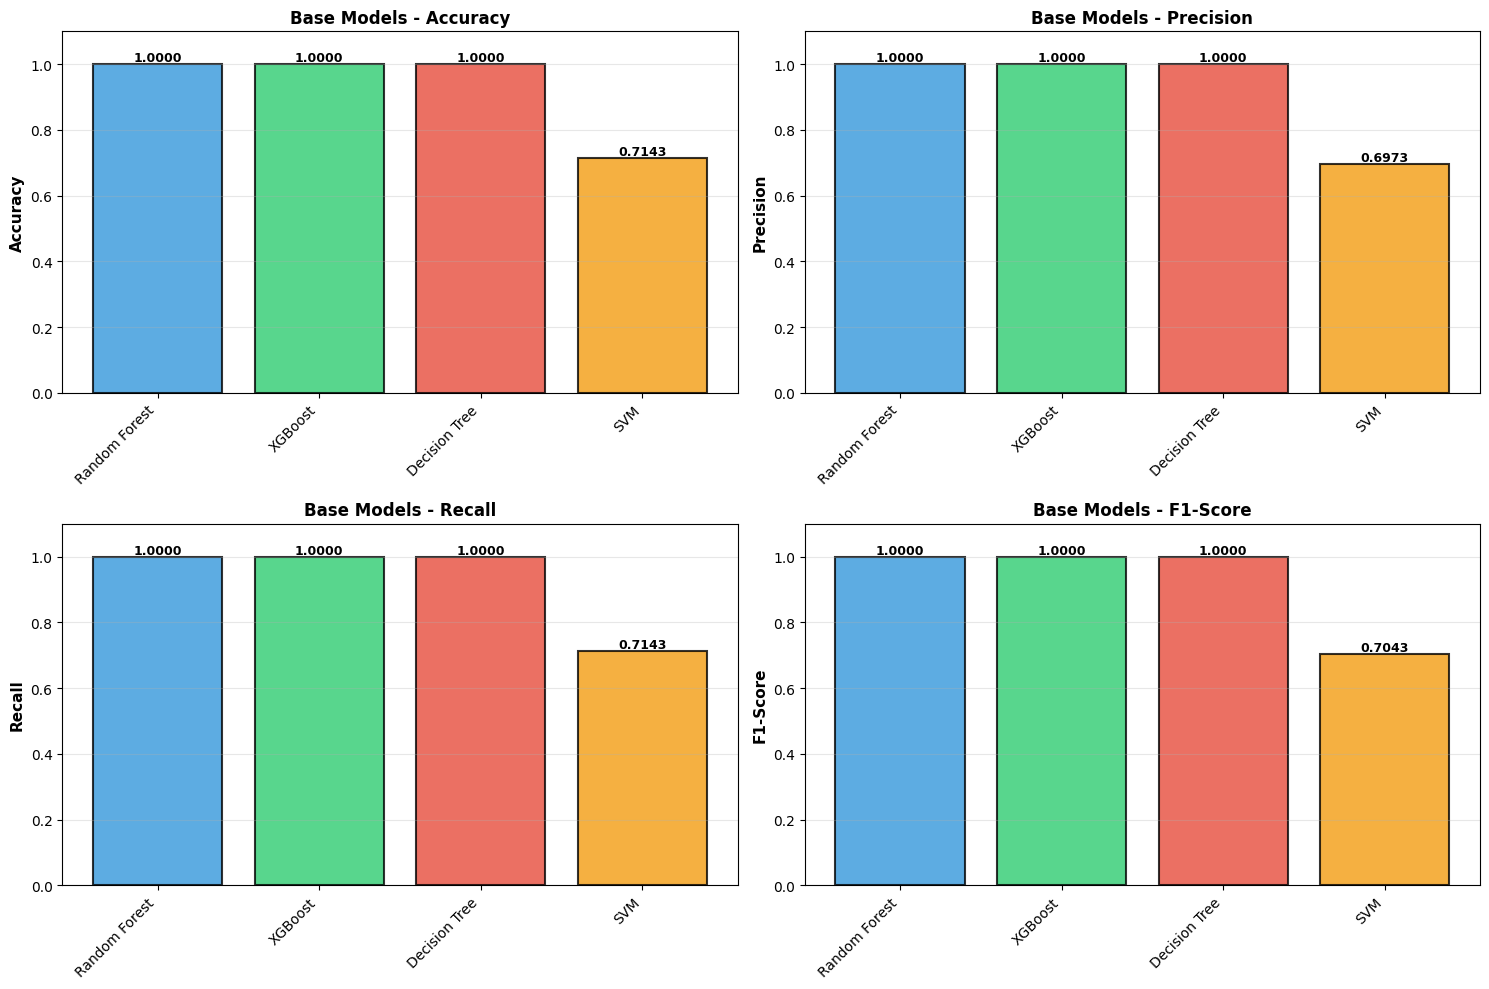

In [95]:
# Visualize Base Models Performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = base_results_df[metric].values
    
    bars = ax.bar(range(len(base_results_df)), values, color=colors_models, 
                edgecolor='black', linewidth=1.5, alpha=0.8)
    
    ax.set_xticks(range(len(base_results_df)))
    ax.set_xticklabels(base_results_df['Model'], rotation=45, ha='right')
    ax.set_ylabel(metric, fontweight='bold', fontsize=11)
    ax.set_title(f'Base Models - {metric}', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Hyperparameter Tuning With GridSearchCV

In [98]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 15],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.05]
    },
    'Decision Tree': {
        'max_depth': [10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'SVM': {
        'C': [0.1, 1],
        'kernel': ['rbf', 'poly']
    }
}

tuned_models = {}
tuned_results = []

for model_name, param_grid in param_grids.items():
    if model_name == 'Random Forest':
        gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1), param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)
    elif model_name == 'XGBoost':
        gs = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0), param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)
    elif model_name == 'Decision Tree':
        gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)
    else:
        gs = GridSearchCV(SVC(random_state=42, probability=True), param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)
    
    gs.fit(X_train_balanced, y_train_balanced)
    tuned_models[model_name] = gs.best_estimator_
    
    y_pred = gs.best_estimator_.predict(X_test)
    tuned_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

tuned_df = pd.DataFrame(tuned_results)
print(tuned_df.to_string(index=False))

        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  1.000000   1.000000 1.000000  1.000000
      XGBoost  1.000000   1.000000 1.000000  1.000000
Decision Tree  1.000000   1.000000 1.000000  1.000000
          SVM  0.705069   0.705069 0.705069  0.705069



BASE vs TUNED COMPARISON:

        Model  Base Accuracy  Tuned Accuracy  Base F1  Tuned F1  F1 Improvement
Random Forest       1.000000        1.000000 1.000000  1.000000        0.000000
      XGBoost       1.000000        1.000000 1.000000  1.000000        0.000000
Decision Tree       1.000000        1.000000 1.000000  1.000000        0.000000
          SVM       0.714286        0.705069 0.704277  0.705069        0.079196


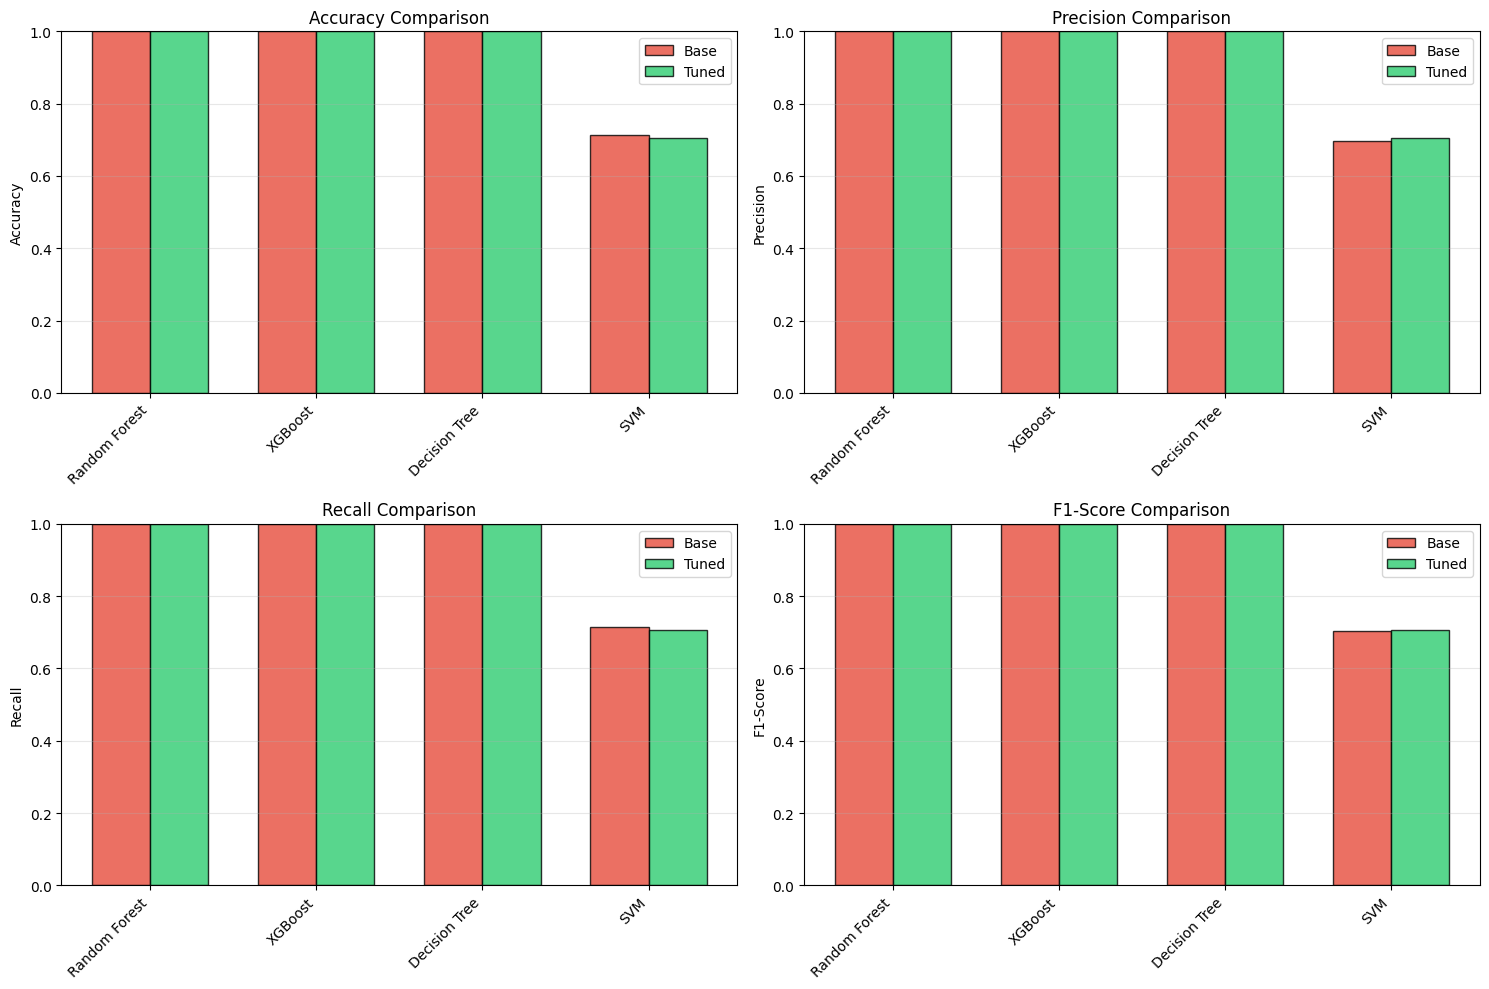

In [100]:
base_vs_tuned = pd.DataFrame({
    'Model': base_results_df['Model'],
    'Base Accuracy': base_results_df['Accuracy'],
    'Tuned Accuracy': tuned_df.set_index('Model').loc[base_results_df['Model'], 'Accuracy'].values,
    'Base F1': base_results_df['F1-Score'],
    'Tuned F1': tuned_df.set_index('Model').loc[base_results_df['Model'], 'F1-Score'].values
})
base_vs_tuned['F1 Improvement'] = (base_vs_tuned['Tuned F1'] - base_vs_tuned['Base F1']) * 100

print("\nBASE vs TUNED COMPARISON:\n")
print(base_vs_tuned.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
models = base_vs_tuned['Model'].values
x = np.arange(len(models))
width = 0.35

for idx, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-Score']):
    ax = axes[idx // 2, idx % 2]
    base_vals = base_results_df[metric].values
    tuned_vals = tuned_df.set_index('Model').loc[models, metric].values
    
    ax.bar(x - width/2, base_vals, width, label='Base', color='#e74c3c', edgecolor='black', alpha=0.8)
    ax.bar(x + width/2, tuned_vals, width, label='Tuned', color='#2ecc71', edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Save The Best Model

In [105]:
best_model_name = tuned_df.loc[tuned_df['F1-Score'].idxmax(), 'Model']
best_model = tuned_models[best_model_name]

model_dir = 'model/P4'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'best_patient_risk_model.pkl')
encoder_path = os.path.join(model_dir, 'feature_encoder.pkl')
features_path = os.path.join(model_dir, 'feature_names.pkl')

joblib.dump(best_model, model_path)
joblib.dump(encoder, encoder_path)
joblib.dump(X_train_balanced.columns.tolist(), features_path)

print(f"Best Model: {best_model_name}")
print(f"Saved to: {os.path.abspath(model_dir)}")
print(f"  {model_path}")
print(f"  {encoder_path}")
print(f"  {features_path}")

Best Model: Random Forest
Saved to: c:\Users\Casper\Desktop\DataScience\Kaggle\healthcare-medallion-ml\notebooks\model\P4
  model/P4\best_patient_risk_model.pkl
  model/P4\feature_encoder.pkl
  model/P4\feature_names.pkl


### Patient Risk Prediction

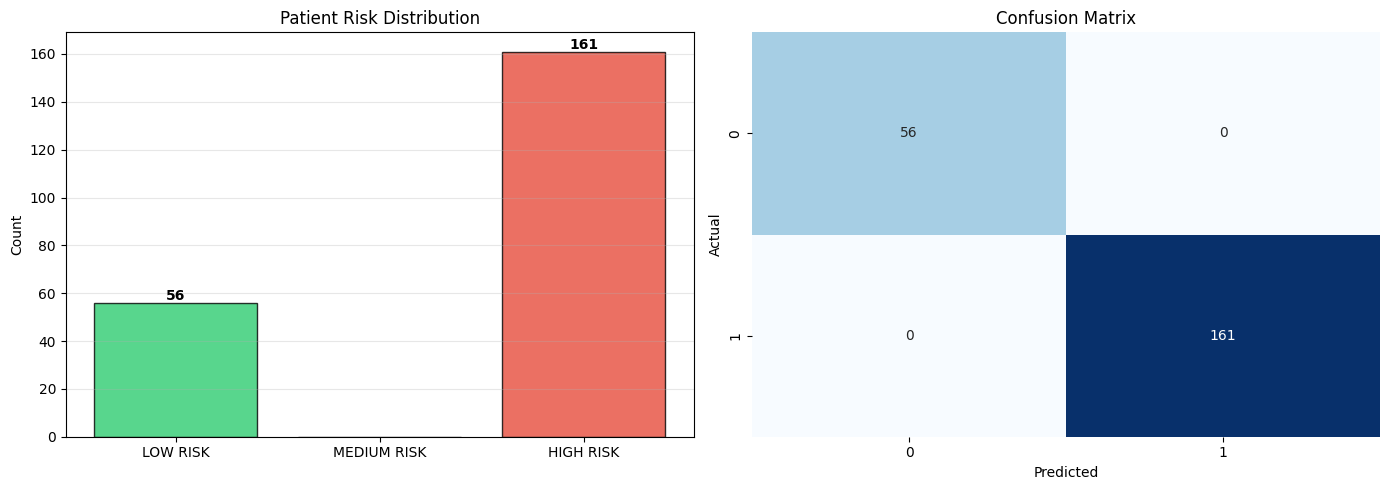

In [109]:
def categorize_risk(prob):
    if prob < 0.33:
        return 'LOW RISK'
    elif prob < 0.67:
        return 'MEDIUM RISK'
    else:
        return 'HIGH RISK'

y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Abnormal_Prob': (y_test_prob * 100).round(2),
    'Risk_Category': [categorize_risk(p) for p in y_test_prob]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_order = ['LOW RISK', 'MEDIUM RISK', 'HIGH RISK']
risk_counts = predictions_df['Risk_Category'].value_counts().reindex(risk_order, fill_value=0)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(risk_order, risk_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Count')
axes[0].set_title('Patient Risk Distribution')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(risk_counts.values):
    if v > 0:
        axes[0].text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()